# Lab 7 — Earthquake catalogue + PostGIS

**Software Engineering for Geoinformatics**

In Lab 6 we built a REST service for the same earthquake catalogue, but the data lived in an Excel file and every endpoint re-read it with pandas. In this lab we migrate the data layer to a real **PostgreSQL/PostGIS** database.

The REST endpoints are **identical** — same URLs, same query parameters, same JSON shape. What changes is what happens *inside* each endpoint:

| Lab 12 | Lab 13 |
|--------|--------|
| `load_df()` reads Excel into a DataFrame | `get_conn()` opens a psycopg connection |
| pandas boolean masks for filtering | SQL `WHERE` clauses |
| `df.groupby(...)` | SQL `GROUP BY` |
| `haversine_km()` function in Python | `ST_DWithin` / `ST_Distance` in PostGIS |
| Manual GeoJSON `{"type":"Point",...}` | `ST_AsGeoJSON(geom)` |
| `pd.concat` + `save_df()` | `INSERT ... RETURNING id` |

> **Requirements.** `flask`, `requests`, `psycopg`, `pandas`, `openpyxl`, `pyjwt`, `matplotlib`.

## 0. First look at the data

The source file is the same Excel sheet from Lab 12.

| column | meaning |
|--------|---------|
| `id` | progressive id |
| `time` | event time (ISO 8601) |
| `lat`, `lon` | epicentre, decimal degrees (WGS-84) |
| `depth_km` | depth in km |
| `magnitude` | local magnitude |
| `zone` | seismic zone label |
| `place` | human-readable location |

In [1]:
import pandas as pd

df = pd.read_excel('earthquakes_italy.xlsx', sheet_name='events')
df['time'] = pd.to_datetime(df['time'])
print('events:', len(df))
df.head()

events: 168


,id,time,lat,lon,depth_km,magnitude,zone,place
0,1,2022-01-20 01:17:14,46.6553,13.2103,16.3,2.1,Friuli - NE Alps,"Friuli - NE Alps (46.66, 13.21)"
1,2,2022-02-11 21:22:55,38.7311,16.2543,13.2,2.7,Calabrian Arc,"Calabrian Arc (38.73, 16.25)"
2,3,2022-02-19 08:56:39,42.0640,13.6851,13.2,2.6,Central Apennines,"Central Apennines (42.06, 13.69)"
3,4,2022-02-19 20:47:01,42.9954,13.8486,16.6,2.2,Central Apennines,"Central Apennines (43.00, 13.85)"
4,5,2022-03-03 17:40:35,44.1653,11.8182,16.4,2.6,Northern Apennines,"Northern Apennines (44.17, 11.82)"


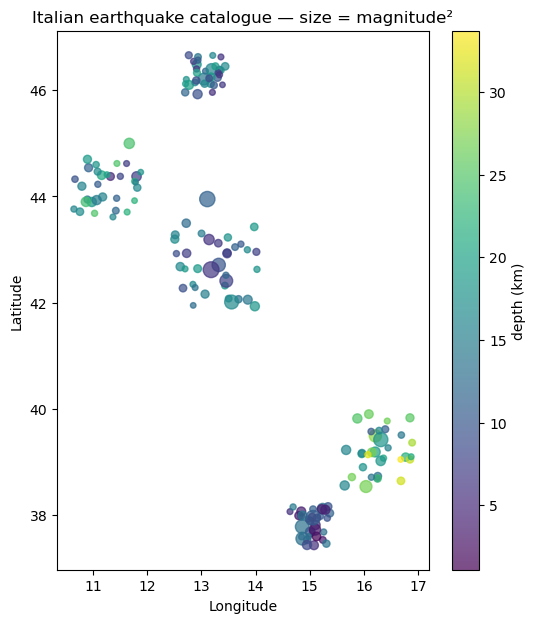

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 7))
sc = ax.scatter(df['lon'], df['lat'],
                s=df['magnitude'] ** 2 * 4,
                c=df['depth_km'], cmap='viridis', alpha=0.7)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Italian earthquake catalogue — size = magnitude²')
plt.colorbar(sc, label='depth (km)')
plt.show()

## 1. The database — seeding

Before starting the Flask server you must load the data into PostgreSQL.
Run this **once** from a terminal in the lab folder:

```
python seed_db.py
```

`seed_db.py` (provided — do not modify) does five things:

1. Creates the `earthquakes_db` database if it does not exist  
2. Enables the PostGIS extension (`CREATE EXTENSION IF NOT EXISTS postgis`)  
3. Creates the `earthquakes` table with a `GEOMETRY(Point, 4326)` column  
4. Loads all 170 events from the Excel file  
5. Creates a GIST spatial index on `geom` for fast proximity queries

### The table schema

```sql
CREATE TABLE earthquakes (
    id        SERIAL           PRIMARY KEY,
    time      TIMESTAMPTZ      NOT NULL,
    lat       DOUBLE PRECISION NOT NULL,
    lon       DOUBLE PRECISION NOT NULL,
    depth_km  DOUBLE PRECISION NOT NULL,
    magnitude DOUBLE PRECISION NOT NULL,
    zone      TEXT             NOT NULL,
    place     TEXT,
    geom      GEOMETRY(Point, 4326)     -- PostGIS column
);
```

The `geom` column stores each event as a 2-D geographic point in WGS-84.
It is populated at insert time with:
```sql
ST_SetSRID(ST_MakePoint(lon, lat), 4326)
--                      ↑    ↑
--            longitude first  (x), latitude second (y)
```

> **Coordinate order.** PostGIS uses `(x, y)` = `(lon, lat)`, the mathematical convention.  
> This is the **opposite** of the human convention "lat, lon" — a very common source of bugs.

In [4]:
# Verify the data made it into PostgreSQL (run after seed_db.py)
import psycopg
from psycopg.rows import dict_row
from db_config import DB_CONFIG

with psycopg.connect(**DB_CONFIG) as conn:
    with conn.cursor(row_factory=dict_row) as cur:
        cur.execute("""
            SELECT COUNT(*)                       AS total,
                   COUNT(geom)                    AS with_geom,
                   MIN(magnitude)                 AS min_mag,
                   MAX(magnitude)                 AS max_mag,
                   MIN(time)::date::text          AS earliest,
                   MAX(time)::date::text          AS latest
            FROM earthquakes
        """)
        row = cur.fetchone()

for k, v in row.items():
    print(f"  {k:12}: {v}")

  total       : 168
  with_geom   : 168
  min_mag     : 2.0
  max_mag     : 5.7
  earliest    : 2022-01-20
  latest      : 2025-12-23


## 2. The REST service — given part

The skeleton `earthquakes_postgis.py` already implements three endpoints backed by SQL queries:

| Method | URL | Query params | Effect |
|--------|-----|--------------|--------|
| `GET` | `/events` | `from`, `to`, `min_mag`, `max_mag`, `zone` | List events filtered by date / magnitude / zone |
| `GET` | `/events/<id>` | — | Single event by primary key |
| `GET` | `/stats/by-zone` | — | Per-zone count, max magnitude, mean depth |

Your job in Section 6 is to add four more using PostGIS spatial functions.

## 3. Starting the service

Open a **new terminal** in the lab folder and run:

```
python earthquakes_postgis.py
```

The service listens on `http://127.0.0.1:5000`.

> If port 5000 is busy on macOS (AirPlay receiver), change `app.run(...)` to  
> `app.run(port=5001, debug=True, use_reloader=False)` and update `BASE_URL` below.

## 4. The client

In [5]:
import requests

BASE_URL = 'http://127.0.0.1:5000'
client   = requests.Session()

def show(resp, n=3):
    print('HTTP', resp.status_code)
    try:
        data = resp.json()
    except Exception:
        print(resp.text); return
    if isinstance(data, list):
        print(f'{len(data)} item(s) — first {n}:')
        for d in data[:n]: print(' ', d)
    else:
        print(data)

print('client ready —', BASE_URL)

client ready — http://127.0.0.1:5000


### 4.1 Filter by date and magnitude

In [6]:
show(client.get(f'{BASE_URL}/events',
                params={'from': '2024-01-01', 'to': '2024-12-31',
                        'min_mag': 4.0}))

HTTP 200
2 item(s) — first 3:
  {'depth_km': 14.3, 'id': 109, 'lat': 46.21, 'lon': 13.05, 'magnitude': 4.3, 'place': 'Friuli - NE Alps (46.21, 13.05)', 'time': '2024-07-04T11:02:18', 'zone': 'Friuli - NE Alps'}
  {'depth_km': 7.5, 'id': 89, 'lat': 42.41, 'lon': 13.46, 'magnitude': 4.6, 'place': 'Central Apennines (42.41, 13.46)', 'time': '2024-02-17T05:46:33', 'zone': 'Central Apennines'}


### 4.2 One event by id

In [7]:
show(client.get(f'{BASE_URL}/events/1'))

HTTP 200
{'depth_km': 16.3, 'id': 1, 'lat': 46.6553, 'lon': 13.2103, 'magnitude': 2.1, 'place': 'Friuli - NE Alps (46.66, 13.21)', 'time': '2022-01-20T01:17:14', 'zone': 'Friuli - NE Alps'}


### 4.3 Per-zone statistics

In [8]:
show(client.get(f'{BASE_URL}/stats/by-zone'), n=10)

HTTP 200
5 item(s) — first 10:
  {'avg_depth': '13.1', 'max_magnitude': 5.7, 'n_events': 35, 'zone': 'Central Apennines'}
  {'avg_depth': '8.5', 'max_magnitude': 5.2, 'n_events': 34, 'zone': 'Etna - Sicily'}
  {'avg_depth': '12.7', 'max_magnitude': 4.3, 'n_events': 33, 'zone': 'Friuli - NE Alps'}
  {'avg_depth': '16.1', 'max_magnitude': 5.5, 'n_events': 33, 'zone': 'Northern Apennines'}
  {'avg_depth': '21.3', 'max_magnitude': 5.1, 'n_events': 33, 'zone': 'Calabrian Arc'}


## 5. Things to notice before the exercises

### The `geom` column vs storing plain `lat`/`lon`

The table keeps both the plain numbers (`lat`, `lon`) **and** the PostGIS geometry column (`geom`). Why?

- `lat` / `lon` are convenient for JSON output — no conversion needed.
- `geom` is what PostGIS operates on. Without it you cannot call `ST_DWithin`, `ST_Distance`, or `ST_AsGeoJSON`.

### The `::geography` cast

PostGIS has two spatial types:

| Type | Unit | When to use |
|------|------|-------------|
| `GEOMETRY` | degrees | 2-D Cartesian maths |
| `GEOGRAPHY` | **metres** | accurate distances on a sphere |

Casting with `geom::geography` makes `ST_DWithin` / `ST_Distance` work in metres instead of degrees — essential for a radius query.

### Coordinate order in `ST_MakePoint`

```python
# Python haversine_km from Lab 12:
haversine_km(lat1, lon1, lat2, lon2)   # lat first

# PostGIS ST_MakePoint:
ST_MakePoint(lon, lat)                 # lon first  ← (x, y) convention
```

If you swap them the point ends up in the ocean.

## 6. Exercises

For each exercise:
1. Add the endpoint to `earthquakes_postgis.py`.
2. Restart the server (`Ctrl-C` then `python earthquakes_postgis.py`).
3. Run the client cell below to test it.

### Exercise 1 — Yearly time-series  `GET /stats/by-year`

Return, for each calendar year, the number of events and the maximum magnitude.

**Hint:** extract the year directly in SQL:
```sql
EXTRACT(YEAR FROM time)::int AS year
```

Compare with Lab 6, where you used:
```python
df.groupby(df['time'].dt.year).agg(...)
```

Expected JSON shape:
```json
[{"year": 2022, "n_events": 38, "max_magnitude": 5.5}, ...]
```

**Client test.** Call `/stats/by-year` and print all rows.

In [ ]:
# Write your code here

### Exercise 2 — Proximity query  `GET /events/near`

Add `GET /events/near?lat=<lat>&lon=<lon>&radius_km=<r>` returning every event within `radius_km` of the given point, sorted by distance ascending. Default `radius_km` to `50` if omitted.

**You must use PostGIS — not a Python haversine function.**

Key functions:
```sql
-- Build a reference point (lon first!)
ST_SetSRID(ST_MakePoint(lon, lat), 4326)

-- Cast to geography so distances are in metres
geom::geography

-- Filter: is the event within radius_metres of the reference?
ST_DWithin(geom::geography, ref::geography, radius_metres)

-- Exact distance in km
ST_Distance(geom::geography, ref::geography) / 1000.0
```

The response should include a `distance_km` field (rounded to 2 decimal places).

**Client test.** Find all events within 50 km of L'Aquila (`lat=42.36`, `lon=13.39`).

In [ ]:
# Write your code here

### Exercise 3 — GeoJSON output  `GET /events.geojson`

Return a valid GeoJSON `FeatureCollection`. Use `ST_AsGeoJSON(geom)` — PostGIS serialises the geometry for you, so you do not need to build `{"type":"Point","coordinates":[...]}` by hand.

```sql
SELECT ST_AsGeoJSON(geom) AS geometry_json
FROM earthquakes
```

`ST_AsGeoJSON` returns a **JSON string** — parse it with `json.loads()` before passing it to `jsonify`.

Support a `min_mag` query parameter. Expected output structure:
```json
{
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "geometry": {"type": "Point", "coordinates": [lon, lat]},
      "properties": {"id": 1, "time": "...", "magnitude": 4.2, ...}
    }
  ]
}
```

**Client test.** Fetch `/events.geojson?min_mag=4.5`, print the number of features, and draw the points on a quick matplotlib map.

In [ ]:
# Write your code here

### Exercise 4 — Authenticated submission  `POST /events`

Add `POST /events` that inserts a new earthquake event into the database. Only users with role `seismologist` may call it.

**Required JSON body fields:** `time`, `lat`, `lon`, `depth_km`, `magnitude`, `zone`

The geometry column must be filled at INSERT time:
```sql
INSERT INTO earthquakes (..., geom)
VALUES (..., ST_SetSRID(ST_MakePoint(lon, lat), 4326))
RETURNING id
```

`RETURNING id` gives you the auto-generated primary key in a single round-trip — no second `SELECT MAX(id)` needed.

Reuse the auth helpers already in `earthquakes_postgis.py` (identical to Lab 12):

```python
USERS = {
    'alice': {'password': 'pwd1',  'role': 'seismologist'},
    'guest': {'password': 'guest', 'role': 'viewer'},
}
```

**Client test** (three steps in order):
1. Try `POST /events` anonymously → expect **401**
2. Log in as `guest`, try `POST /events` → expect **403**
3. Log in as `alice`, submit a new event → expect **201**

In [ ]:
# Write your code here — anonymous (expect 401)


In [ ]:
# Write your code here — guest (expect 403)


In [ ]:
# Write your code here — alice cookie (expect 201)


In [ ]:
# Bonus: repeat the POST using a JWT token instead of a cookie session
